In [1]:
# dependencies
import pandas as pd
import scipy
import scipy.interpolate as sci_int
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sci_stats
import cartopy.crs as ccrs
import geopandas as gpd
import geodatasets
import shapely
import xarray

import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from matplotlib.colors import LinearSegmentedColormap


from sklearn.preprocessing import MinMaxScaler
import hdbscan

from joblib import Parallel, delayed
from fast_histogram import histogram2d
import pyarrow

In [2]:
beach = pd.read_parquet('undrogued_beach.parquet')

In [3]:
N_Pacific_ids = np.array(pd.read_csv('watershed_ids/N_Pacific_ids.csv')).flatten()
W_Pacific_ids = np.array(pd.read_csv('watershed_ids/W_Pacific_ids.csv')).flatten()
SW_Pacific_ids = np.array(pd.read_csv('watershed_ids/SW_Pacific_ids.csv')).flatten()
N_Indian_ids = np.array(pd.read_csv('watershed_ids/N_Indian_ids.csv')).flatten()
W_Indian_ids = np.array(pd.read_csv('watershed_ids/W_Indian_ids.csv')).flatten()
Mid_Atlantic_ids = np.array(pd.read_csv('watershed_ids/Mid_Atlantic_ids.csv')).flatten()
NE_Atlantic_ids = np.array(pd.read_csv('watershed_ids/NE_Atlantic_ids.csv')).flatten()
NW_Atlantic_ids = np.array(pd.read_csv('watershed_ids/NW_Atlantic_ids.csv')).flatten()
SO_West_Australia_ids = np.array(pd.read_csv('watershed_ids/SO_West_Australia_ids.csv')).flatten()
SO_East_Australia_ids = np.array(pd.read_csv('watershed_ids/SO_East_Australia_ids.csv')).flatten()
Tasman_Sea_ids = np.array(pd.read_csv('watershed_ids/Tasman_Sea_ids.csv')).flatten()
W_Central_Pacific_ids = np.array(pd.read_csv('watershed_ids/W_Central_Pacific_ids.csv')).flatten()
S_Central_Pacific_ids = np.array(pd.read_csv('watershed_ids/S_Central_Pacific_ids.csv')).flatten()
SW_Atlantic_ids = np.array(pd.read_csv('watershed_ids/SW_Atlantic_ids.csv')).flatten()
SO_S_America_ids = np.array(pd.read_csv('watershed_ids/SO_S_America_ids.csv')).flatten()
E_Central_Pacific_ids = np.array(pd.read_csv('watershed_ids/E_Central_Pacific_ids.csv')).flatten()

In [4]:
watersheds = {
    'N_Pacific': beach[beach['id'].isin(N_Pacific_ids)][['id','lat', 'lon','time_to_beach']],
    'W_Pacific': beach[beach['id'].isin(W_Pacific_ids)][['id','lat', 'lon','time_to_beach']],
    'SW_Pacific': beach[beach['id'].isin(SW_Pacific_ids)][['id','lat', 'lon','time_to_beach']],
    'N_Indian': beach[beach['id'].isin(N_Indian_ids)][['id','lat', 'lon','time_to_beach']],
    'W_Indian': beach[beach['id'].isin(W_Indian_ids)][['id','lat', 'lon','time_to_beach']],
    'Mid_Atlantic': beach[beach['id'].isin(Mid_Atlantic_ids)][['id','lat', 'lon','time_to_beach']],
    'NE_Atlantic': beach[beach['id'].isin(NE_Atlantic_ids)][['id','lat', 'lon','time_to_beach']],
    'NW_Atlantic': beach[beach['id'].isin(NW_Atlantic_ids)][['id','lat', 'lon','time_to_beach']],
    'SO_West_Australia': beach[beach['id'].isin(SO_West_Australia_ids)][['id','lat', 'lon','time_to_beach']],
    'SO_East_Australia': beach[beach['id'].isin(SO_East_Australia_ids)][['id','lat', 'lon','time_to_beach']],
    'Tasman_Sea': beach[beach['id'].isin(Tasman_Sea_ids)][['id','lat', 'lon','time_to_beach']],
    'W_Central_Pacific': beach[beach['id'].isin(W_Central_Pacific_ids)][['id','lat', 'lon','time_to_beach']],
    'S_Central_Pacific': beach[beach['id'].isin(S_Central_Pacific_ids)][['id','lat', 'lon','time_to_beach']],    
    'SW_Atlantic': beach[beach['id'].isin(SW_Atlantic_ids)][['id','lat', 'lon','time_to_beach']],
    'SO_S_America': beach[beach['id'].isin(SO_S_America_ids)][['id','lat', 'lon','time_to_beach']],
    'E_Central_Pacific': beach[beach['id'].isin(E_Central_Pacific_ids)][['id','lat', 'lon','time_to_beach']],
}

In [5]:
beaching_points = beach.loc[beach.groupby('id')['time_to_beach'].idxmin()]

In [6]:
beaching_coooords = (np.array(beaching_points['lat']),np.array(beaching_points['lon']))

In [7]:
N_Pacific_beach = beaching_points[beaching_points['id'].isin(N_Pacific_ids)][['lat', 'lon']]
W_Pacific_beach = beaching_points[beaching_points['id'].isin(W_Pacific_ids)][['lat', 'lon']]
SW_Pacific_beach = beaching_points[beaching_points['id'].isin(SW_Pacific_ids)][['lat', 'lon']]
N_Indian_beach = beaching_points[beaching_points['id'].isin(N_Indian_ids)][['lat', 'lon']]
W_Indian_beach = beaching_points[beaching_points['id'].isin(W_Indian_ids)][['lat', 'lon']]
Mid_Atlantic_beach = beaching_points[beaching_points['id'].isin(Mid_Atlantic_ids)][['lat', 'lon']]
NE_Atlantic_beach = beaching_points[beaching_points['id'].isin(NE_Atlantic_ids)][['lat', 'lon']]
NW_Atlantic_beach = beaching_points[beaching_points['id'].isin(NW_Atlantic_ids)][['lat', 'lon']]
SO_West_Australia_beach = beaching_points[beaching_points['id'].isin(SO_West_Australia_ids)][['lat', 'lon']]
SO_East_Australia_beach = beaching_points[beaching_points['id'].isin(SO_East_Australia_ids)][['lat', 'lon']]
Tasman_Sea_beach = beaching_points[beaching_points['id'].isin(Tasman_Sea_ids)][['lat', 'lon']]
W_Central_Pacific_beach = beaching_points[beaching_points['id'].isin(W_Central_Pacific_ids)][['lat', 'lon']]
S_Central_Pacific_beach = beaching_points[beaching_points['id'].isin(S_Central_Pacific_ids)][['lat', 'lon']]
SW_Atlantic_beach = beaching_points[beaching_points['id'].isin(SW_Atlantic_ids)][['lat', 'lon']]
SO_S_America_beach = beaching_points[beaching_points['id'].isin(SO_S_America_ids)][['lat', 'lon']]
E_Central_Pacific_beach = beaching_points[beaching_points['id'].isin(E_Central_Pacific_ids)][['lat', 'lon']]

beaching_dict = {
    'N_Pacific': N_Pacific_beach,
    'W_Pacific': W_Pacific_beach,
    'SW_Pacific': SW_Pacific_beach,
    'N_Indian': N_Indian_beach,
    'W_Indian': W_Indian_beach,
    'Mid_Atlantic': Mid_Atlantic_beach,
    'NE_Atlantic': NE_Atlantic_beach,
    'NW_Atlantic': NW_Atlantic_beach,
    'SO_West_Australia': SO_West_Australia_beach,
    'SO_East_Australia': SO_East_Australia_beach,
    'Tasman_Sea': Tasman_Sea_beach,
    'W_Central_Pacific': W_Central_Pacific_beach,
    'S_Central_Pacific': S_Central_Pacific_beach,
    'SW_Atlantic': SW_Atlantic_beach,
    'SO_S_America': SO_S_America_beach,
    'E_Central_Pacific': E_Central_Pacific_beach,
}

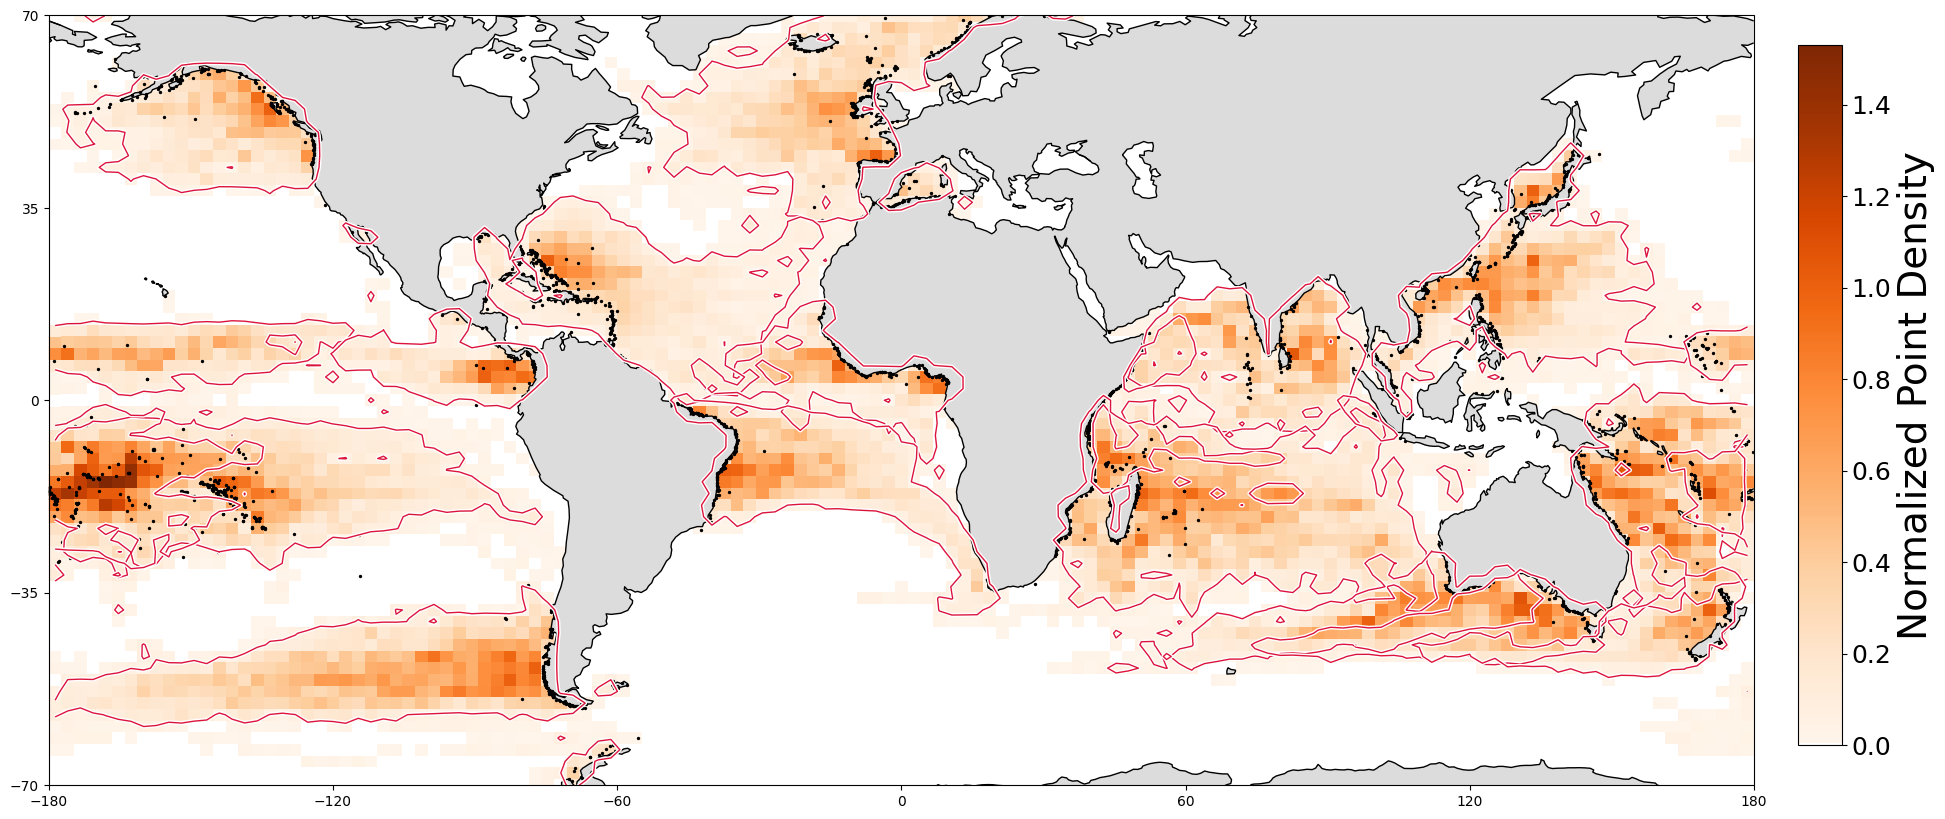

In [8]:
# Load world shapefile
world = gpd.read_file(geodatasets.data.naturalearth.land.path)

#grid for the heatmap
n_lons, n_lats = 135, 85  # Number of grid cells
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)
lon_centers_cluster = (lon_bins[1:] + lon_bins[:-1]) / 2
lat_centers_cluster = (lat_bins[1:] + lat_bins[:-1]) / 2

# filter data to within a year
def year_to_beach(cluster):
    year = 31536000  # Number of seconds in 1 year
    # Make a copy of the filtered cluster to avoid the warning
    if (cluster['time_to_beach'] <= year).any():
        filtered_cluster = cluster[cluster['time_to_beach'] <= year].copy()
    return filtered_cluster

def preprocess_data(df):
    # Ensure df is modified safely with .loc and make a copy if needed
    df.loc[:, 'lat'] = pd.to_numeric(df['lat'], errors='coerce')
    df.loc[:, 'lon'] = pd.to_numeric(df['lon'], errors='coerce')
    df.dropna(subset=['lat', 'lon'], inplace=True)
    
    return df

def process_watersheds(watershed_names, watersheds):
    # Create a figure for the plot
    fig = plt.figure(figsize=(22, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
    ax.set_ylim(-70, 70)
    # Adjust the position of the plot box for better width control
   # ax.set_position([0.05, 0.05, 0.9, 0.9])  # [left, bottom, width, height]

    cmap = plt.colormaps["Oranges"].resampled(256)

    # Modify the colormap by adding white at the lowest end
    new_colors = cmap(np.linspace(0, 1, 256))
    new_colors[0] = [1, 1, 1, 1]  # Set the first color to white (R, G, B, Alpha)

    # Create a new colormap with the modified colors
    custom_cmap = LinearSegmentedColormap.from_list("custom_oranges", new_colors)
    
    contour_handles = []
    
    heatmap_data_normalized12_list = np.zeros((85, 135))
    for j, watershed_name in enumerate(watershed_names):
        # Filter the data for 1 year (12 months) using the new function
        filtered_data_12m = preprocess_data(year_to_beach(watersheds[watershed_name]))
       # print(filtered_data_12m)
        
        latitudes12 = list(filtered_data_12m['lat'].values)
        longitudes12 = list(filtered_data_12m['lon'].values)

        # Calculate the 2D histogram (density plot) of point density for 12 months
        heatmap_data12, _, _ = np.histogram2d(latitudes12, longitudes12, bins=[lat_bins, lon_bins], density=True)

        # Normalize the 12-month data
        heatmap_data_normalized12 = (heatmap_data12 - np.min(heatmap_data12)) / (np.max(heatmap_data12) - np.min(heatmap_data12))

        # Plot contours for the normalized data
        linewidths = [3]
      #  linestyless = ['-', '--', ':', '-.']
        contour = plt.contour(
            lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12,
            #[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)
            levels=[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)], 
            colors='white', linewidths=linewidths[0], 
            transform=ccrs.PlateCarree()
        )
      #  contour_handles.append(contour.collections[0])
        
        # Add additional contour with crimson color
        contour = plt.contour(
            lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12,
            levels=[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)],
            colors='crimson', linestyles='solid', linewidths=1,
            transform=ccrs.PlateCarree()
        )
      #  contour_handles.append(contour.collections[0])

        heatmap_data_normalized12_list += heatmap_data_normalized12
    # Plot the filled contour for normalized heatmaps
    mesh = ax.pcolormesh(lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12_list, cmap=custom_cmap, transform=ccrs.PlateCarree())

    # Plot the land polygons
    world.plot(ax=ax, color='gainsboro', edgecolor='none')

    # Plot legend
    contour_handles = [
        Line2D([0], [0], color='lightcoral', linewidth=2)
        for watershed in watershed_names
    ]

    for watershed_name in watershed_names:
        plt.scatter(beaching_dict[watershed_name]['lon'], beaching_dict[watershed_name]['lat'], 
                    color='k', s=2)
 #   beach_coords_handle = mlines.Line2D([], [], color='k', marker='o', linestyle='None', markersize=10, label='beach coords')
#
   # ax.legend(contour_handles + [beach_coords_handle], watershed_names + ['beaching locations'], loc='upper right', bbox_to_anchor=(0.83, 1.02), fontsize=18)

    # Add colorbar with increased tick size and label text size
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = plt.colorbar(mesh, cax = cbar_ax, label='Normalized Point Density')
    cbar.ax.tick_params(labelsize=18)  # Increase tick size
    cbar.set_label('Normalized Point Density', size=28)  # Increase label text size
    
    ax.set_aspect('auto')
    
    ax.coastlines(color = 'black')
    
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-70, -35, 0, 35, 70])
    
    #plt.savefig(f"final_watersheds/watersheds_poster_{'_'.join(watershed_names)}.png")
    
    
# Define combinations of watersheds
combinations = [
    (['NE_Atlantic', 'NW_Atlantic', 'N_Pacific','SW_Pacific', 'N_Indian', 'S_Central_Pacific', 'W_Indian','W_Pacific','Mid_Atlantic','SO_West_Australia' ,'SO_East_Australia', 'Tasman_Sea','W_Central_Pacific', 'SW_Atlantic', 'SO_S_America', 'E_Central_Pacific'], watersheds)
]

for watershed_names, watersheds in combinations:
    process_watersheds(watershed_names, watersheds)



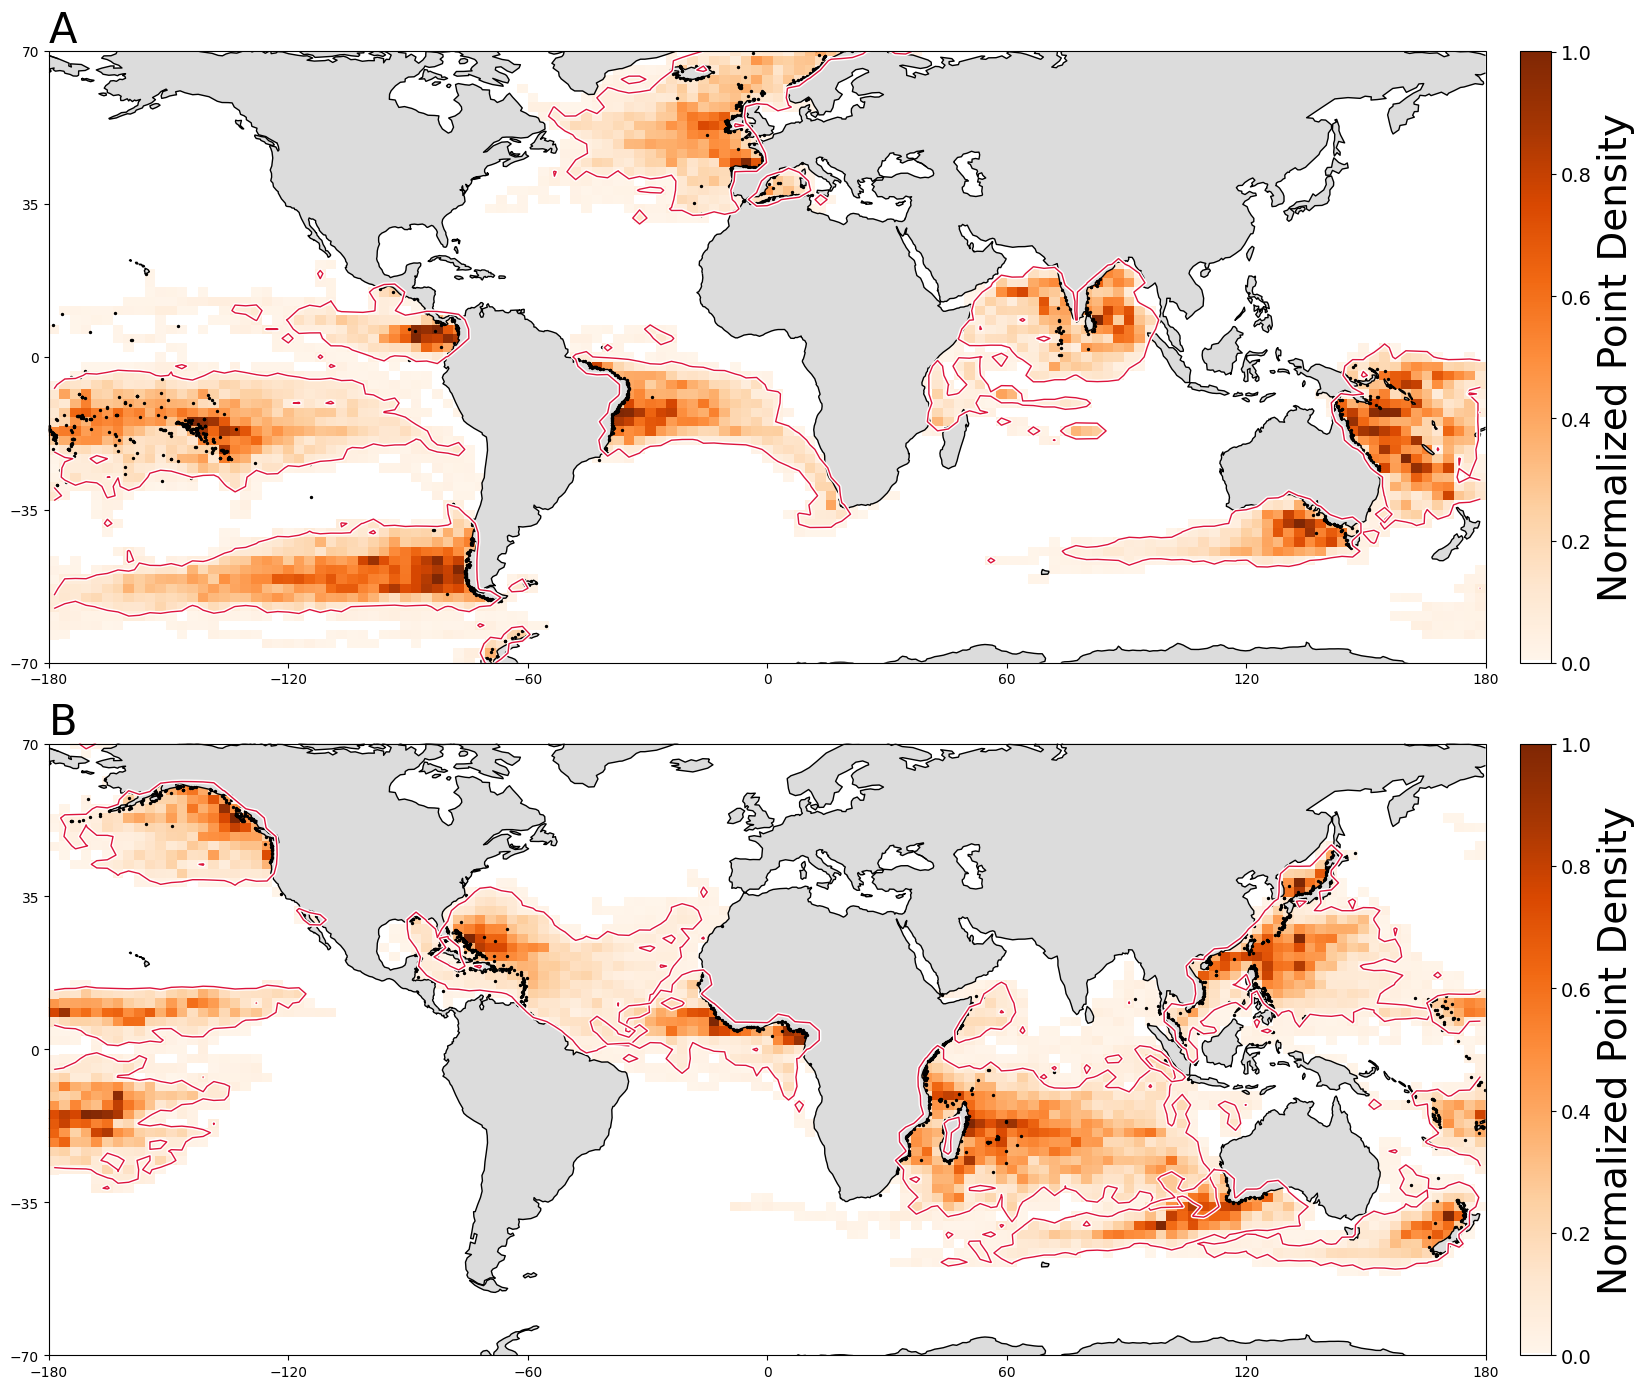

In [9]:
# Define combinations of watersheds
combinations = [
    (['NE_Atlantic', 'SW_Pacific', 'SO_East_Australia', 'SO_S_America', 'SW_Atlantic', 'N_Indian', 'E_Central_Pacific', 'S_Central_Pacific'], watersheds),
    (['NW_Atlantic', 'Tasman_Sea', 'Mid_Atlantic','W_Indian', 'SO_West_Australia', 'W_Pacific', 'W_Central_Pacific', 'N_Pacific'], watersheds),
]
fig, axes = plt.subplots(2, 1, figsize=(18, 14),
                         subplot_kw={'projection': ccrs.PlateCarree()})

labels = ['A', 'B']

def process_watersheds_on_ax(ax, watershed_names, watersheds, label):

    ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
    ax.set_ylim(-70, 70)

    cmap = plt.colormaps["Oranges"].resampled(256)

    new_colors = cmap(np.linspace(0, 1, 256))
    new_colors[0] = [1, 1, 1, 1]
    custom_cmap = LinearSegmentedColormap.from_list("custom_oranges", new_colors)

    heatmap_data_normalized12_list = np.zeros((85, 135))

    for watershed_name in watershed_names:
        filtered_data_12m = preprocess_data(year_to_beach(watersheds[watershed_name]))

        latitudes12 = filtered_data_12m['lat'].values
        longitudes12 = filtered_data_12m['lon'].values

        heatmap_data12, _, _ = np.histogram2d(
            latitudes12, longitudes12,
            bins=[lat_bins, lon_bins], density=True
        )

        heatmap_data_normalized12 = (
            heatmap_data12 - np.min(heatmap_data12)
        ) / (np.max(heatmap_data12) - np.min(heatmap_data12))

        # contours
        ax.contour(
            lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12,
            levels=[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)],
            colors='white', linewidths=3,
            transform=ccrs.PlateCarree()
        )

        ax.contour(
            lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12,
            levels=[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)],
            colors='crimson', linewidths=1,
            transform=ccrs.PlateCarree()
        )

        heatmap_data_normalized12_list += heatmap_data_normalized12

    # heatmap
    mesh = ax.pcolormesh(
        lon_centers_cluster, lat_centers_cluster,
        heatmap_data_normalized12_list,
        cmap=custom_cmap,
        transform=ccrs.PlateCarree()
    )

    # land + coast
    world.plot(ax=ax, color='gainsboro', edgecolor='none')
    ax.coastlines(color='black')

    # beaching points
    for watershed_name in watershed_names:
        ax.scatter(
            beaching_dict[watershed_name]['lon'],
            beaching_dict[watershed_name]['lat'],
            color='k', s=2
        )

    ax.set_aspect('auto')
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-70, -35, 0, 35, 70])

    # panel label
    ax.set_title(label, loc='left', fontweight='bold', fontsize=30)

    # individual colorbar
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label('Normalized Point Density', size=28)


# --- run panels ---
for ax, (watershed_names, watersheds), label in zip(axes, combinations, labels):
    process_watersheds_on_ax(ax, watershed_names, watersheds, label)

plt.tight_layout()
#plt.savefig("figs/watersheds", dpi=300)
plt.show()

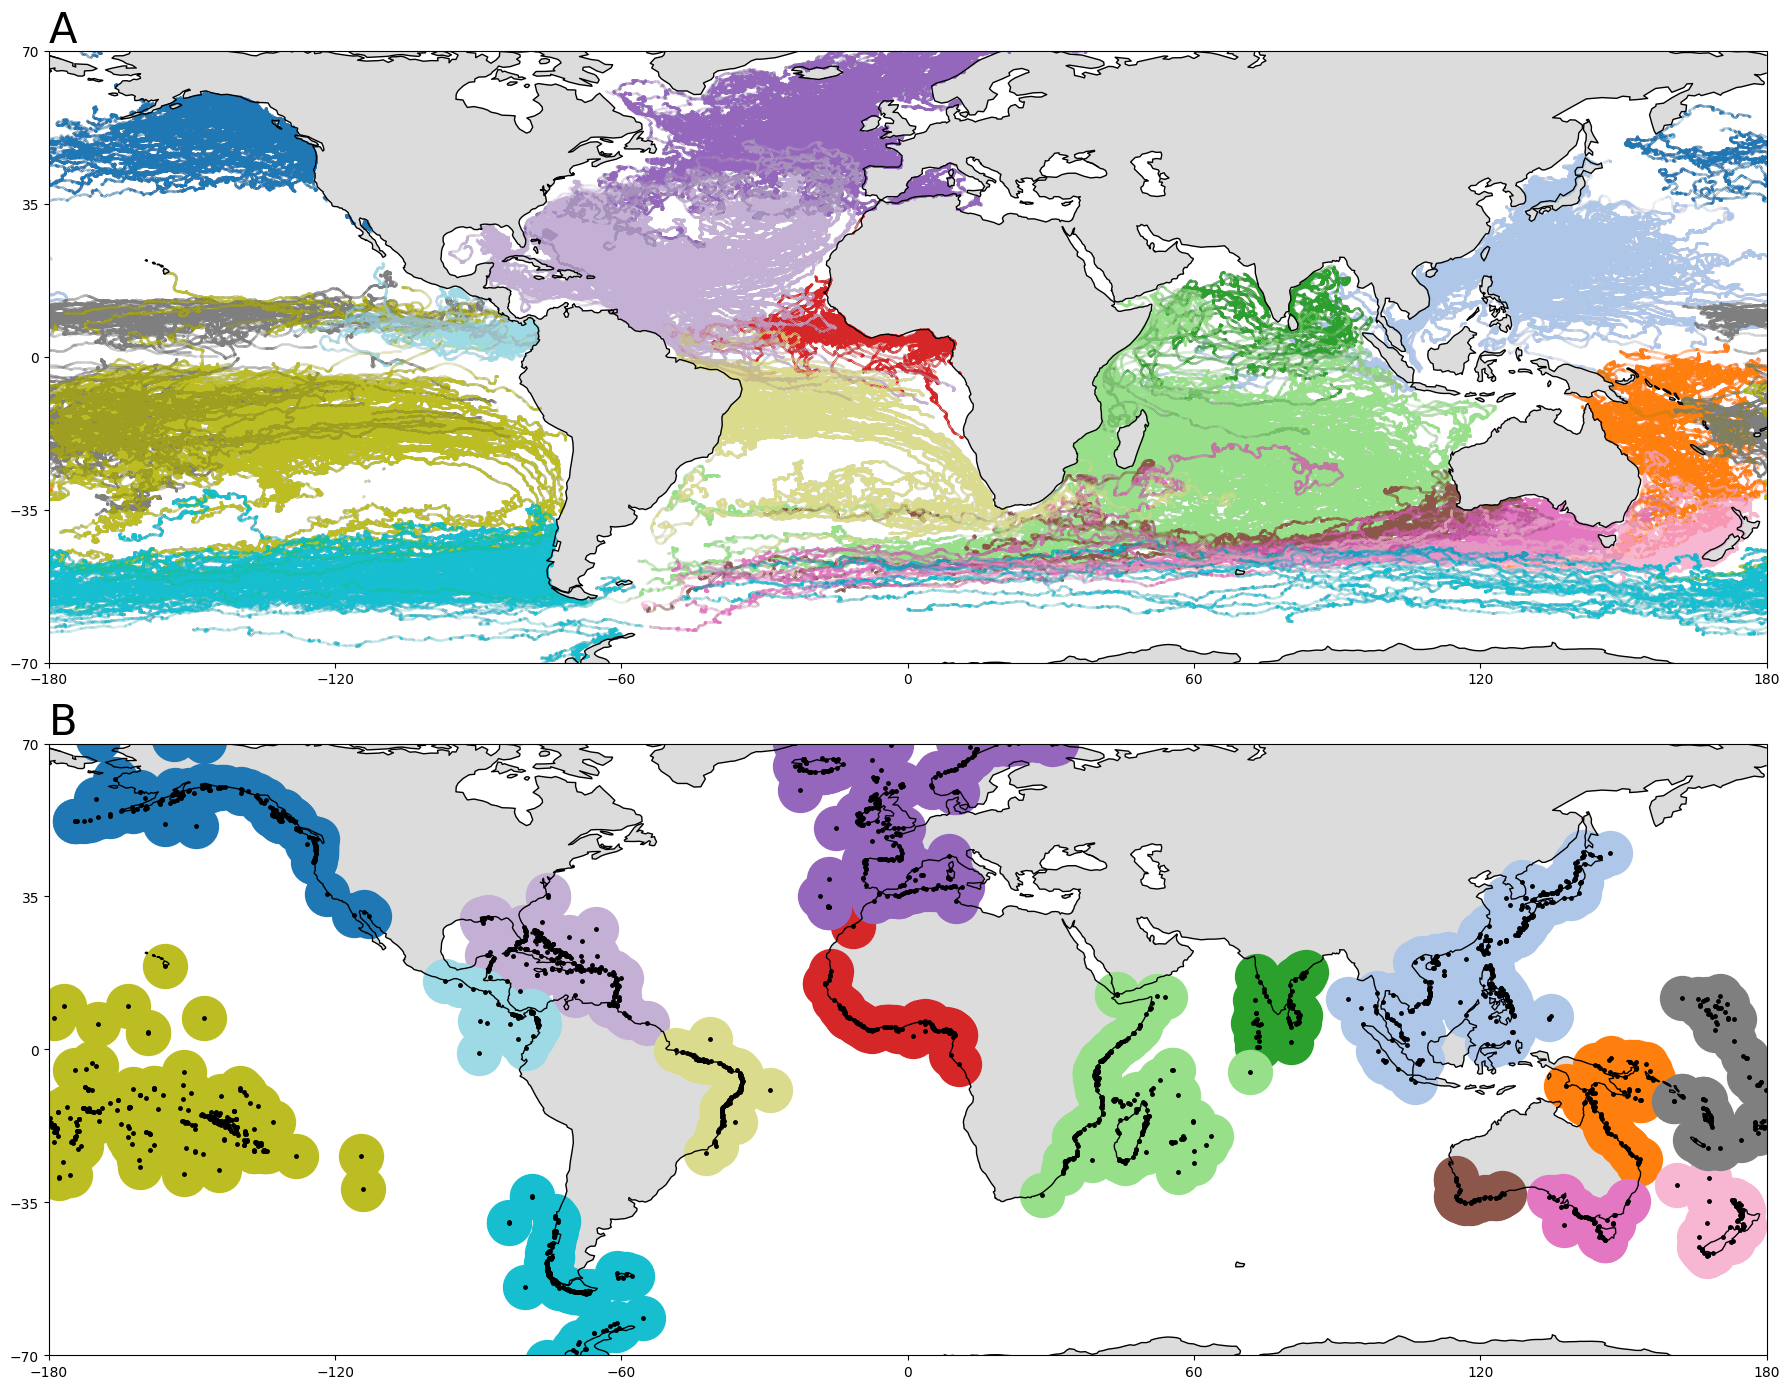

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 14),
                               subplot_kw={'projection': ccrs.PlateCarree()})

paired_cmap = plt.get_cmap('tab20')
colors = paired_cmap(np.linspace(0, 1, 16))
watershed_colors = {str(w): colors[i] for i, w in enumerate(watersheds)}

for ax in (ax1, ax2):
    ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
    ax.set_ylim(-70, 70)
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-70, -35, 0, 35, 70])
    world.plot(ax=ax, color='gainsboro', edgecolor='none')
    ax.coastlines(color='black')
    ax.set_aspect('auto')

# --- A: trajectories ---
for watershed in watersheds:
    color_indice = watershed_colors[str(watershed)]
    ax1.scatter(
        watersheds[str(watershed)]['lon'],
        watersheds[str(watershed)]['lat'],
        marker='o',
        color=color_indice,
        alpha=0.7,
        s=0.001
    )

ax1.set_title('A', fontweight='bold', loc='left', fontsize=30)

# --- B: beaching points ---
for watershed in watersheds:
    color_indice = watershed_colors[str(watershed)]
    ax2.scatter(
        beaching_dict[str(watershed)]['lon'], 
        beaching_dict[str(watershed)]['lat'], 
        marker='o',
        color=color_indice,
        s=1000
    )

for watershed in watersheds:
    ax2.scatter(
        beaching_dict[str(watershed)]['lon'], 
        beaching_dict[str(watershed)]['lat'], 
        marker='.',
        color='k',
        s=25
    )

ax2.set_title('B', fontweight='bold', loc='left', fontsize=30)

# # --- Invisible colorbars to fix layout ---
# import matplotlib as mpl

# dummy = mpl.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(0, 1))
# dummy.set_array([])

# for ax in (ax1, ax2):
#     cbar = fig.colorbar(dummy, ax=ax, orientation='vertical', pad=0.02)
#     cbar.ax.set_alpha(0)              # fully transparent
#     cbar.outline.set_visible(False)
#     cbar.set_ticks([])

plt.tight_layout()
#plt.savefig("figs/ocean_delineation_beaching", dpi=300)
plt.show()

In [15]:
beach_clusters = pd.read_parquet('/home/codycruz/drifters_watersheds/watershed_stability_outputs/watershed_stability_3regime_200_main_diag_13894720/regime2/consensus_cluster_df.parquet')
drogued_beach = pd.read_csv('/home/codycruz/drifters_watersheds/drogued_beach_new.csv')

In [13]:
noise_rows = beach_clusters[beach_clusters["HDBSCAN"] == -1]

In [20]:
noise_traj_df = beach[beach["id"].isin(noise_rows["id"])]

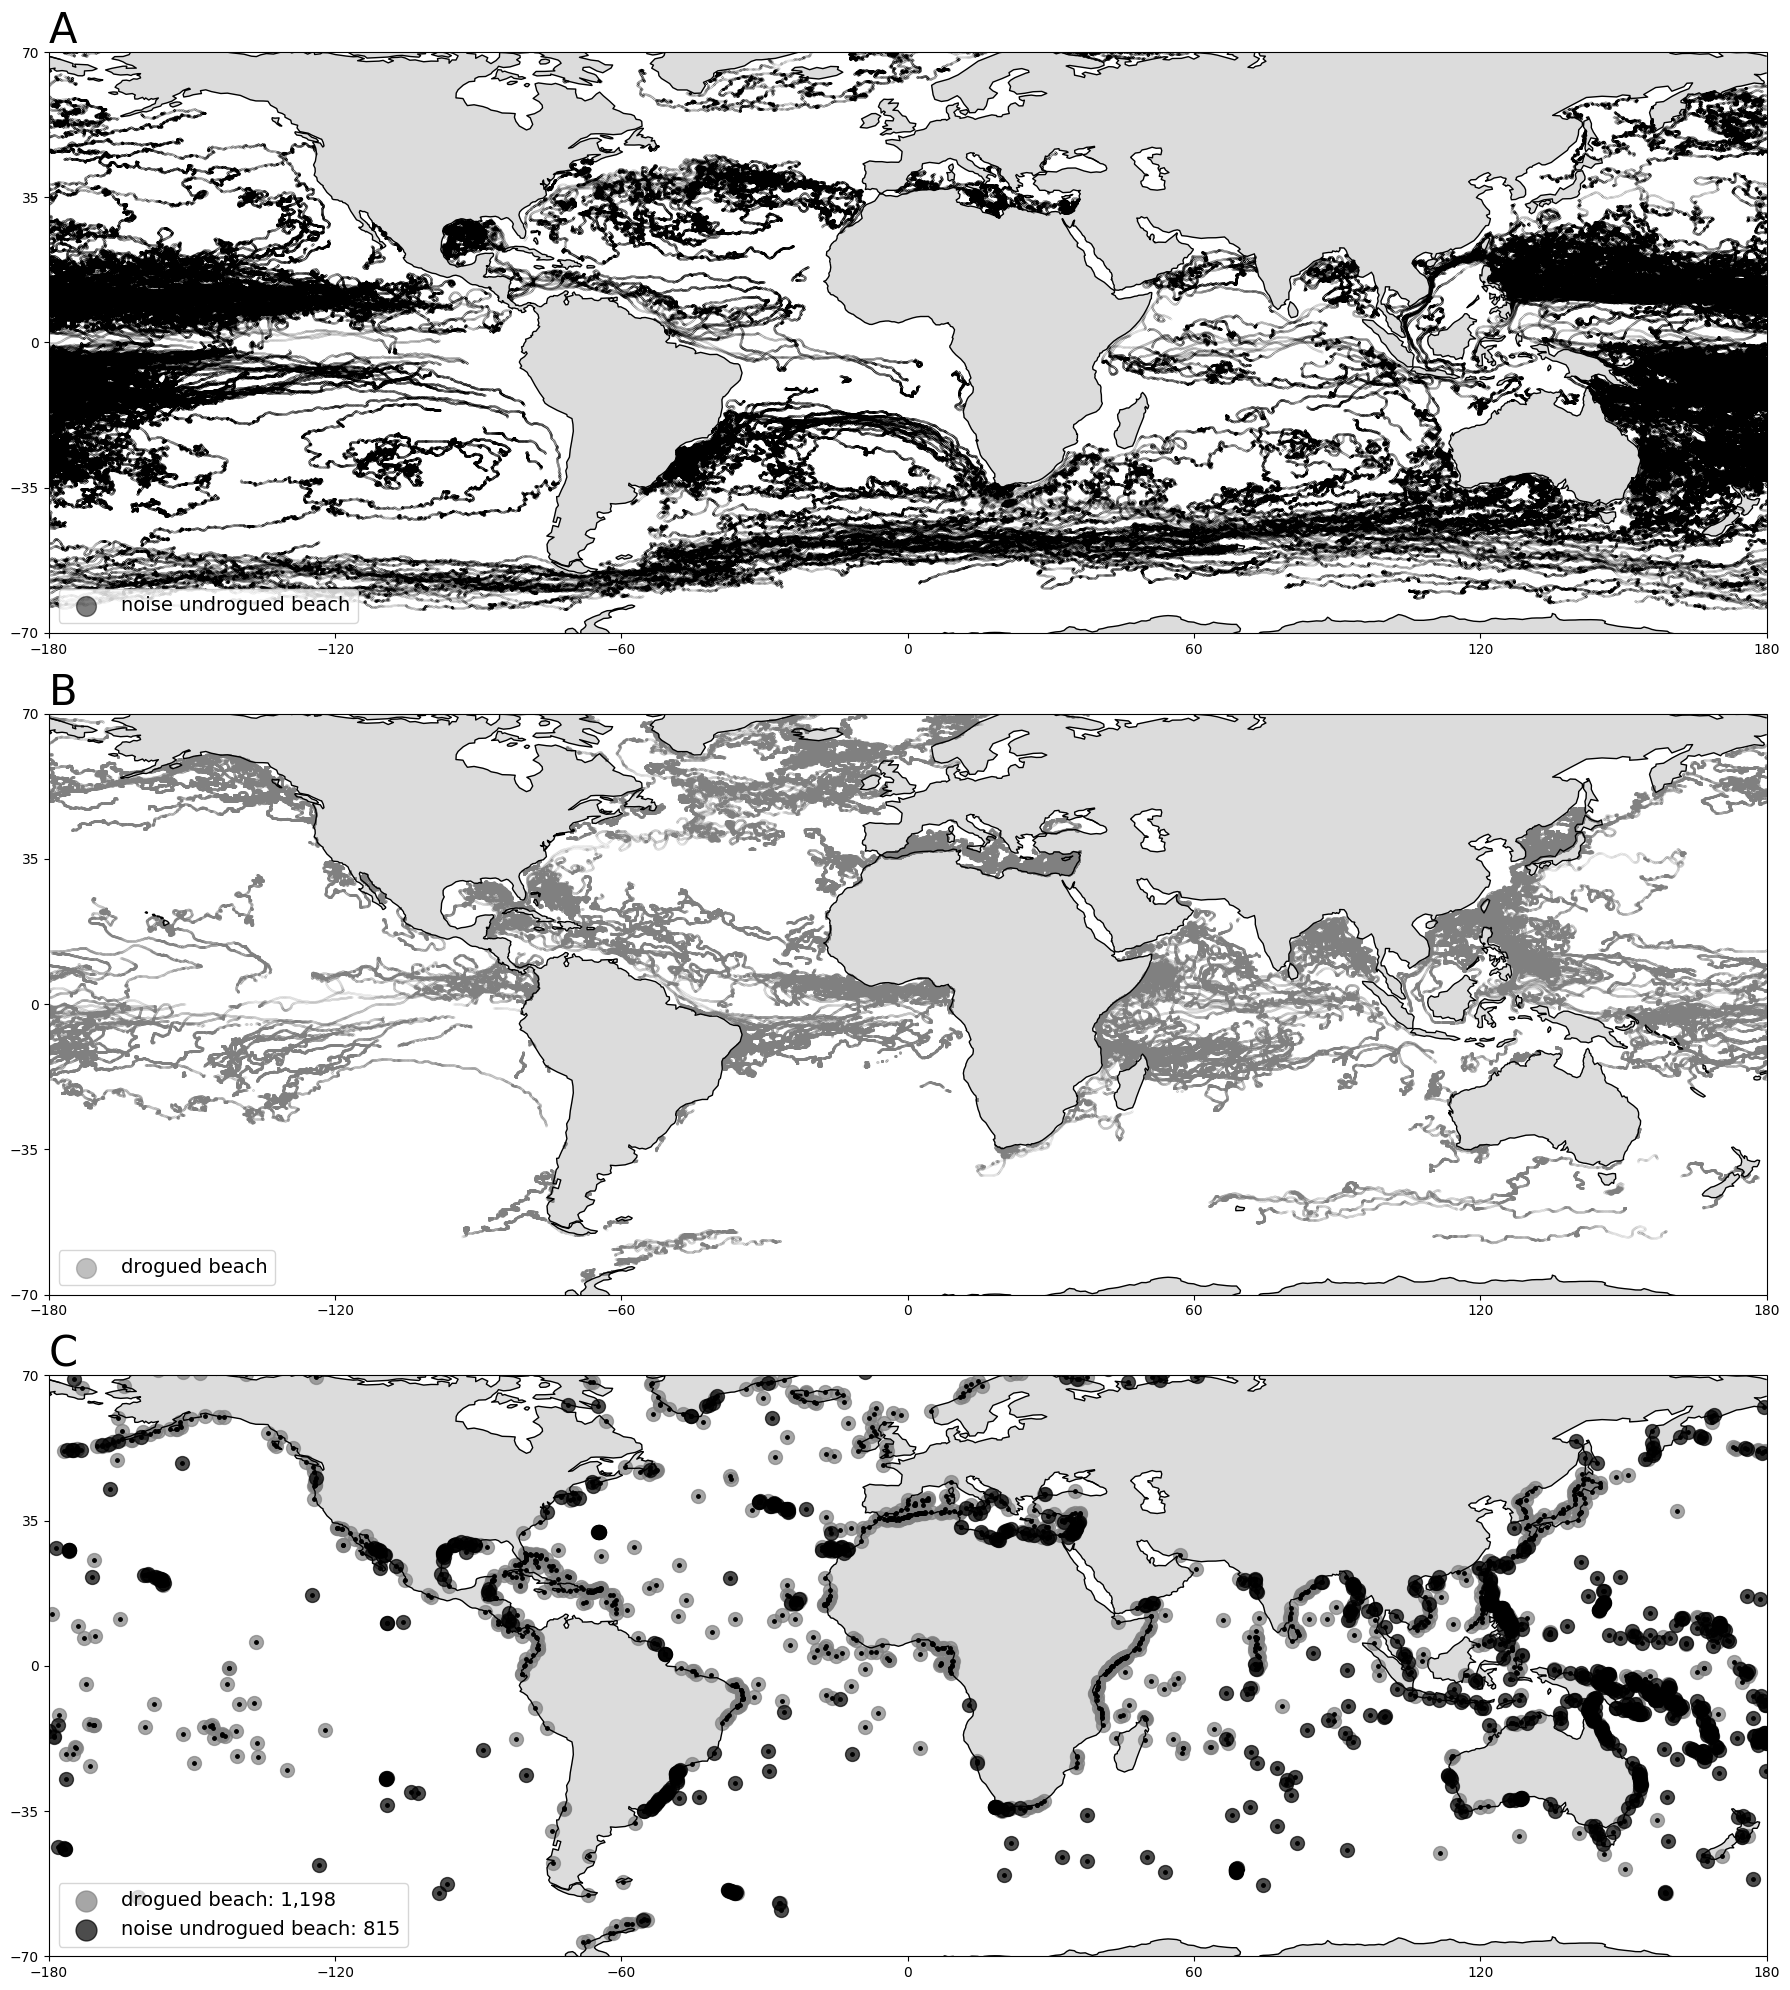

In [37]:
# Beaching subsets
drogued_beaching = drogued_beach[drogued_beach["time_to_beach"] == 0]
noise_beaching = noise_traj_df[noise_traj_df["time_to_beach"] == 0]

# Unique trajectory counts
N = drogued_beaching["id"].nunique()
W = noise_beaching["id"].nunique()

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(18, 20),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax in (ax1, ax2, ax3):
    ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
    ax.set_ylim(-70, 70)
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-70, -35, 0, 35, 70])

    world.plot(ax=ax, color="gainsboro", edgecolor="none")
    ax.coastlines(color="black")
    ax.set_aspect("auto")

# --------------------------------------------------
# A: noise undrogued beach trajectories
# --------------------------------------------------
ax1.scatter(
    noise_traj_df["lon"],
    noise_traj_df["lat"],
    marker="o",
    color="black",
    alpha=0.5,
    s=0.001,
    transform=ccrs.PlateCarree(),
    label="noise undrogued beach"
)

ax1.set_title(
    "A",
    fontweight="bold",
    loc="left",
    fontsize=30
)

ax1.legend(
    markerscale=450,
    loc="lower left",
    fontsize=14
)

# --------------------------------------------------
# B: drogued beach trajectories
# --------------------------------------------------
ax2.scatter(
    drogued_beach["lon"],
    drogued_beach["lat"],
    marker="o",
    color="gray",
    alpha=0.5,
    s=0.001,
    transform=ccrs.PlateCarree(),
    label="drogued beach"
)

ax2.set_title(
    "B",
    fontweight="bold",
    loc="left",
    fontsize=30
)

ax2.legend(
    markerscale=450,
    loc="lower left",
    fontsize=14
)

# --------------------------------------------------
# C: beaching coordinates
# --------------------------------------------------
drogued_beaching = drogued_beach[
    drogued_beach["time_to_beach"] == 0
]

noise_beaching = noise_traj_df[
    noise_traj_df["time_to_beach"] == 0
]

# drogued beach
ax3.scatter(
    drogued_beaching["lon"],
    drogued_beaching["lat"],
    marker="o",
    color="gray",
    alpha=0.7,
    s=100,
    transform=ccrs.PlateCarree(),
    label=f"drogued beach: {N:,}"
)

ax3.scatter(
    noise_beaching["lon"],
    noise_beaching["lat"],
    marker="o",
    color="black",
    alpha=0.7,
    s=100,
    transform=ccrs.PlateCarree(),
    label=f"noise undrogued beach: {W:,}"
)

# center dots
ax3.scatter(
    drogued_beaching["lon"],
    drogued_beaching["lat"],
    marker=".",
    color="k",
    s=25,
    transform=ccrs.PlateCarree()
)

ax3.scatter(
    noise_beaching["lon"],
    noise_beaching["lat"],
    marker=".",
    color="k",
    s=25,
    transform=ccrs.PlateCarree()
)

ax3.set_title(
    "C",
    fontweight="bold",
    loc="left",
    fontsize=30
)

ax3.legend(
    markerscale=1.5,
    loc="lower left",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "figs/noise_vs_drogued_beach_3panel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()